# Segmentation + skills library building

## Initialization

In [1]:
from itertools import cycle
import shutil
import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from pathlib import Path
from collections import OrderedDict
from sklearn.preprocessing import MinMaxScaler, PolynomialFeatures
from sklearn.metrics import f1_score, accuracy_score
from sklearn.model_selection import TimeSeriesSplit
from sklearn.metrics import r2_score, accuracy_score
import datetime as dt

# from scipy import signal
from scipy.interpolate import make_splrep

# from scipy.interpolate import UnivariateSpline
import os
from pathlib import Path
from tqdm.auto import tqdm
from pprint import pprint
import ruptures as rpt
from ruptures.metrics import precision_recall, hausdorff, randindex
import distancia

In [2]:
from segmentation_utils import (
    # extract_eef_data_from_rosbag,
    get_ground_truth_segmentation,
    # get_bagfiles_from_json,
    read_h5_data,
    get_gtdict_filenames,
    ts2df,
)

In [3]:
from LfD_Library.MP_Library import gen_traj, MP_Library
from LfD_Library.sim_metrics import *
from ElasticMaps.elmap_EM import ElmapEM

In [4]:
mpl.rcParams["font.family"] = ["serif"]
# mpl.rcParams["font.serif"] = [
#     "Times New Roman",
#     "Computer Modern",
#     "DejaVu Serif",
#     "Liberation Serif",
#     "Roboto",
#     "Latin Modern Roman"
# ]

In [5]:
# Make transparent background plot
TRANSP_BACK_PLOT = True
# TRANSP_BACK_PLOT = False

In [6]:
# %matplotlib ipympl
%load_ext autoreload
%autoreload 2

## Data files

In [7]:
# data_path_root = Path("../table-task-ur5e")
data_path_root = Path(".") / "data"
assert data_path_root.exists()

In [8]:
ground_truth_segm_file = Path(".") / "segm_ground_truth.json"
ground_truth_segm_file.exists()

True

In [9]:
# bagfiles = get_bagfiles_from_json(ground_truth_segm_file=ground_truth_segm_file)
# bagfiles

In [10]:
filenum = 4
# bagfile = bagfiles[filenum]
# bagfile

In [11]:
gt_segm_dict, video_file, hdf5_file = get_gtdict_filenames(
    ground_truth_segm_file=ground_truth_segm_file, filenum=filenum
)
pprint(gt_segm_dict)

{'hdf5': 'set-table-1.h5',
 'segments': {'grasping': [{'end': 1769722515, 'ini': 1769722513},
                           {'end': 1769722528, 'ini': 1769722526}],
              'placing': [{'end': 1769722520, 'ini': 1769722515},
                          {'end': 1769722532, 'ini': 1769722528}],
              'reaching': [{'end': 1769722513, 'ini': 1769722509},
                           {'end': 1769722526, 'ini': 1769722523}],
              'releasing': [{'end': 1769722523, 'ini': 1769722520},
                            {'end': 1769722534, 'ini': 1769722532}]},
 'synchro_ts': 0,
 'synchro_vid': 0,
 'video': 'set-table-1.MOV'}


In [12]:
hdf5_path = data_path_root / hdf5_file
video_path = data_path_root / video_file

## Preprocessing

In [13]:
joint_data, tf_data, wrench_data, gripper_data = read_h5_data(fname=hdf5_path)

['gripper_info', 'joint_state_info', 'transform_info', 'wrench_info']


In [14]:
# traj = extract_eef_data_from_rosbag(bagfile)
traj = ts2df(tf_data=tf_data, gripper_data=gripper_data)
traj

,x,y,z,timestamp,gripper
0,0.133374,-0.491946,0.488060,2026-01-29 16:35:00.061860719-05:00,0.01
1,0.133347,-0.491951,0.488074,2026-01-29 16:35:00.063833920-05:00,0.01
2,0.133355,-0.491946,0.488115,2026-01-29 16:35:00.065845539-05:00,0.01
3,0.133380,-0.491974,0.488051,2026-01-29 16:35:00.067825505-05:00,0.01
4,0.133364,-0.491962,0.488054,2026-01-29 16:35:00.069813187-05:00,0.01
...,...,...,...,...,...
19865,0.135927,-0.588379,0.150828,2026-01-29 16:35:39.814759299-05:00,0.01
19866,0.135922,-0.588352,0.150850,2026-01-29 16:35:39.816785764-05:00,0.01
19867,0.135941,-0.588375,0.150808,2026-01-29 16:35:39.818760903-05:00,0.01
19868,0.135917,-0.588353,0.150842,2026-01-29 16:35:39.820763520-05:00,0.01


In [15]:
# df = traj.diff().mean().timestamp.total_seconds()
# df

In [16]:
# downsampling = 10

In [17]:
# freq = 1 / (df * downsampling)
# freq

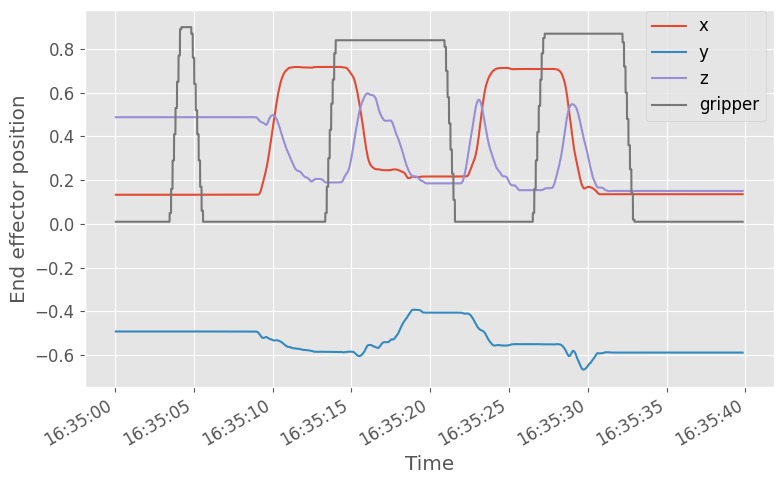

In [18]:
with plt.style.context("ggplot_perso.mplstyle"):
    # with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(8, 5))
    # cmap = mpl.colormaps.get("tab10").colors
    ax.plot(traj.timestamp, traj.x, label="x")  # , color=cmap[0])
    ax.plot(traj.timestamp, traj.y, label="y")  # , color=cmap[1])
    ax.plot(traj.timestamp, traj.z, label="z")  # , color=cmap[2])
    ax.plot(traj.timestamp, traj.gripper, label="gripper")  # , color=cmap[3])
    ax.set_xlabel("Time")
    ax.set_ylabel("End effector position")
    # ax.legend(loc="best")
    ax.legend(bbox_to_anchor=(1.0, 1.02))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

## Ground truth segmentation

In [19]:
# gt_segm_dict = get_ground_truth_segmentation(
#     ground_truth_segm_file=ground_truth_segm_file, bagfile=bagfile
# )
# pprint(gt_segm_dict)

### Adding more features

#### Objects moving activation functions

In [20]:
nsegments = 0
obj_labels = []
for segm_key, segm_val in gt_segm_dict["segments"].items():
    if isinstance(segm_val, list):
        nsegments += len(segm_val)
        for jdx, _ in enumerate(segm_val):
            obj_labels.append(f"obj_{segm_key}_{jdx + 1}")
    elif isinstance(segm_val, dict):
        nsegments += 1
        obj_labels.append(f"obj_{segm_key}")
    else:
        raise ValueError("Unexpected value in ground truth JSON file")
nsegments, obj_labels

(8,
 ['obj_reaching_1',
  'obj_reaching_2',
  'obj_grasping_1',
  'obj_grasping_2',
  'obj_placing_1',
  'obj_placing_2',
  'obj_releasing_1',
  'obj_releasing_2'])

In [21]:
objects = np.zeros((traj.shape[0], nsegments))
objects.shape

(19870, 8)

In [22]:
col_i = 0
for sect_i, sect_key in enumerate(gt_segm_dict["segments"].keys()):
    sect_dict_current = gt_segm_dict["segments"][sect_key]
    if isinstance(sect_dict_current, list):
        for sect_j, sect_cur in enumerate(sect_dict_current):
            xs = traj.timestamp[
                (
                    traj.timestamp
                    > pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_cur["ini"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
                & (
                    traj.timestamp
                    < pd.Timestamp(
                        dt.datetime.fromtimestamp(sect_cur["end"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
            ]
            print(col_i)
            objects[xs.index, col_i] = np.ones_like(xs)
            col_i += 1

    elif isinstance(sect_dict_current, dict):
        xs = traj.timestamp[
            (
                traj.timestamp
                > pd.Timestamp(
                    dt.datetime.fromtimestamp(sect_dict_current["ini"]),
                    # - dt.timedelta(hours=1),
                    tz="EST",
                )
            )
            & (
                traj.timestamp
                < pd.Timestamp(
                    dt.datetime.fromtimestamp(sect_dict_current["end"]),
                    # - dt.timedelta(hours=1),
                    tz="EST",
                )
            )
        ]
        print(col_i)
        objects[xs.index, col_i] = np.ones_like(xs)
        col_i += 1
    else:
        raise ValueError("Unexpected value in ground truth JSON file")

objects

0
1
2
3
4
5
6
7


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(19870, 8))

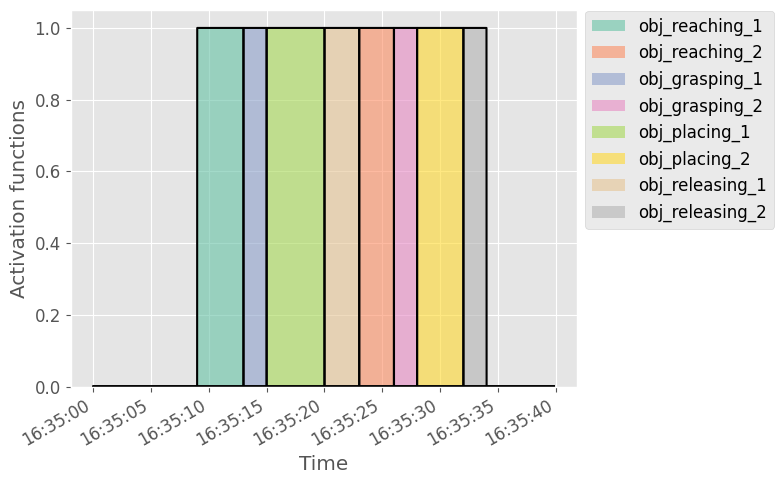

In [23]:
with plt.style.context("ggplot_perso.mplstyle"):
    cmap = mpl.colormaps.get("Set2").colors
    fig, ax = plt.subplots(figsize=(8, 5))
    for idx in range(objects.shape[1]):
        ax.plot(
            traj.timestamp,
            objects[:, idx],
            # label=obj_labels[idx],
            color="k",
            # linewidth=1.5,
        )
    ax.stackplot(
        traj.timestamp,
        objects.T,
        labels=obj_labels,
        alpha=0.6,
        colors=cmap,
    )
    ax.set_xlabel("Time")
    ax.set_ylabel("Activation functions")
    # ax.legend(loc="best")
    ax.legend(bbox_to_anchor=(1.0, 1.02))
    fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

In [24]:
for idx in range(objects.shape[1]):
    traj[obj_labels[idx]] = objects[:, idx]
traj

,x,y,z,timestamp,gripper,obj_reaching_1,obj_reaching_2,obj_grasping_1,obj_grasping_2,obj_placing_1,obj_placing_2,obj_releasing_1,obj_releasing_2
0,0.133374,-0.491946,0.488060,2026-01-29 16:35:00.061860719-05:00,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.133347,-0.491951,0.488074,2026-01-29 16:35:00.063833920-05:00,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.133355,-0.491946,0.488115,2026-01-29 16:35:00.065845539-05:00,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.133380,-0.491974,0.488051,2026-01-29 16:35:00.067825505-05:00,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.133364,-0.491962,0.488054,2026-01-29 16:35:00.069813187-05:00,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
19865,0.135927,-0.588379,0.150828,2026-01-29 16:35:39.814759299-05:00,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19866,0.135922,-0.588352,0.150850,2026-01-29 16:35:39.816785764-05:00,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19867,0.135941,-0.588375,0.150808,2026-01-29 16:35:39.818760903-05:00,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19868,0.135917,-0.588353,0.150842,2026-01-29 16:35:39.820763520-05:00,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [25]:
# def add_more_features(ground_truth_segm_file, bagfile, traj):
#     # Get the ground truth data for the BAG file
#     gt_segm_dict = get_ground_truth_segmentation(
#         ground_truth_segm_file=ground_truth_segm_file, bagfile=bagfile
#     )

#     # Initialize the matrix
#     objects = np.zeros((traj.shape[0], len(gt_segm_dict["HigherLevel"].keys())))

#     # Set to ones for each object when it's moving
#     for sect_i, sect_key in enumerate(gt_segm_dict["HigherLevel"].keys()):
#         sect_dict_current = gt_segm_dict["HigherLevel"][sect_key]
#         xs = traj.timestamp[
#             (
#                 traj.timestamp
#                 > pd.Timestamp(
#                     dt.datetime.fromtimestamp(sect_dict_current["ini"])
#                     - dt.timedelta(hours=1),
#                     tz="EST",
#                 )
#             )
#             & (
#                 traj.timestamp
#                 < pd.Timestamp(
#                     dt.datetime.fromtimestamp(sect_dict_current["end"])
#                     - dt.timedelta(hours=1),
#                     tz="EST",
#                 )
#             )
#         ]
#         objects[xs.index, sect_i] = np.ones_like(xs)

#     # Merge with the original DataFrame
#     for idx in range(objects.shape[1]):
#         traj[list(gt_segm_dict["HigherLevel"].keys())[idx]] = objects[:, idx]
#     return traj

### Plot segments

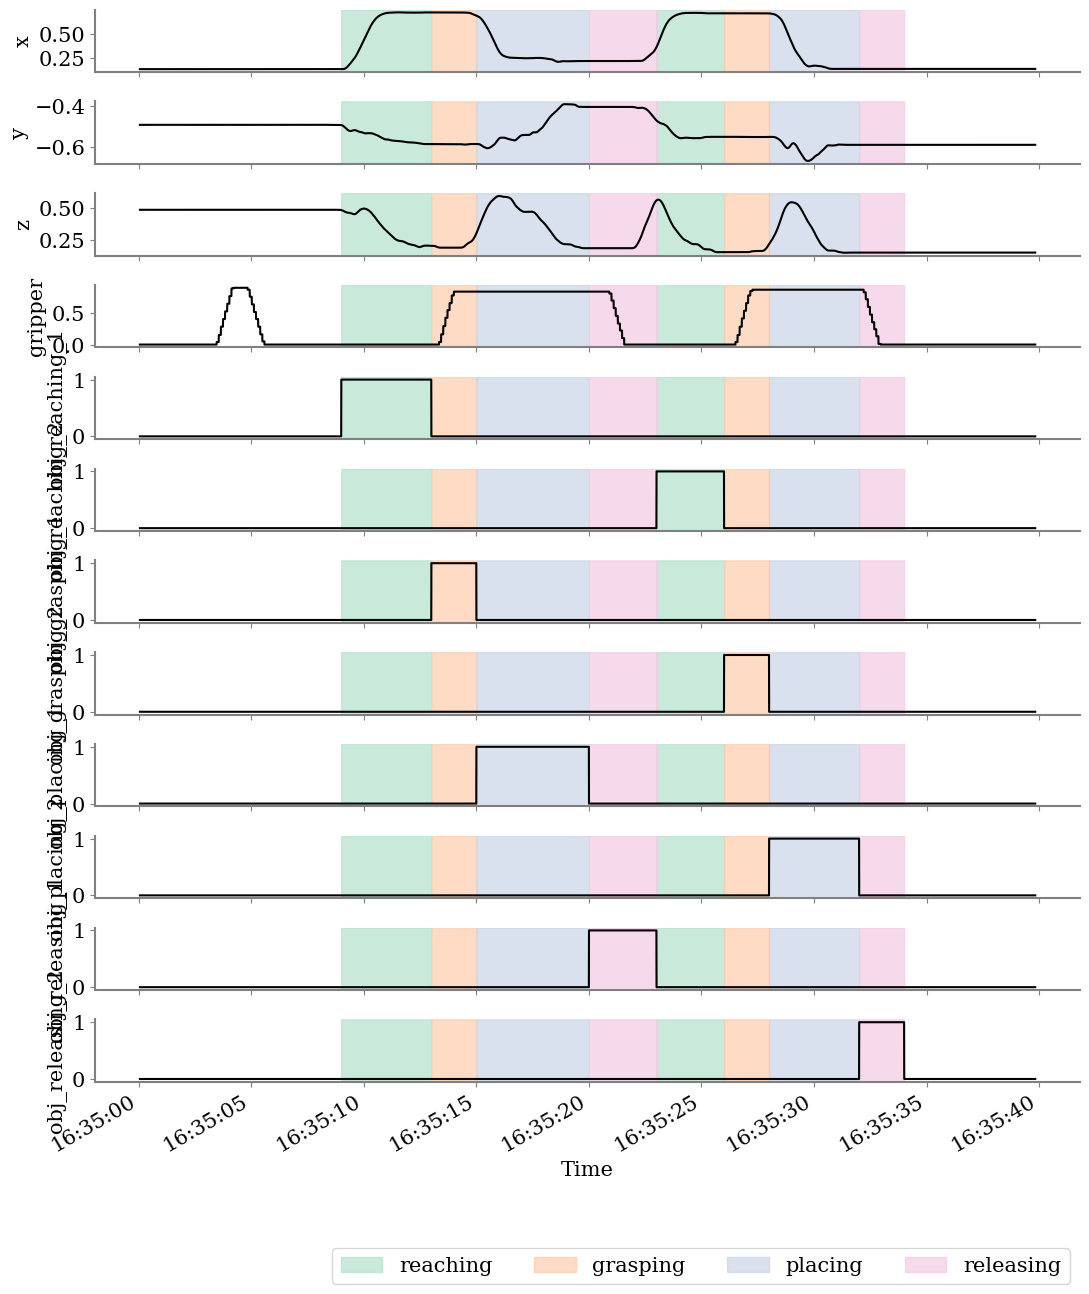

In [26]:
df_labels = list(traj.drop(columns=["timestamp"]).keys())
fig, axes = plt.subplots(
    nrows=len(df_labels),
    ncols=1,
    sharex=True,
    sharey=False,
    figsize=(11, len(df_labels)),
)
cmap = mpl.colormaps.get("Pastel2").colors
labels_fontsize = 15
for idx, ax in enumerate(axes):
    for item in (
        [ax.title, ax.xaxis.label, ax.yaxis.label]
        + ax.get_xticklabels()
        + ax.get_yticklabels()
    ):
        item.set_fontsize(labels_fontsize)

    ax.plot(traj.timestamp, traj[df_labels[idx]], "k")
    ax.set_ylabel(df_labels[idx])

    y_low = traj[df_labels[idx]].min()
    y_high = traj[df_labels[idx]].max()
    y_range = np.abs(y_high - y_low) / 2
    y_top = y_high + 0.1 * y_range
    y_bottom = y_low - 0.1 * y_range
    ax.set_ylim(bottom=y_bottom, top=y_top)
    ax.spines[["right", "top"]].set_visible(False)
    if TRANSP_BACK_PLOT:
        ax.patch.set_alpha(0)
    ax.tick_params(color="gray")
    for spine in ax.spines.values():
        spine.set_edgecolor("gray")
        spine.set_linewidth(1.5)

    for sect_i, sect_key in enumerate(gt_segm_dict["segments"].keys()):
        skill_current = gt_segm_dict["segments"][sect_key]
        if isinstance(skill_current, list):
            for skill_i, skill_val in enumerate(skill_current):
                xs = traj.timestamp[
                    (
                        traj.timestamp
                        > pd.Timestamp(
                            dt.datetime.fromtimestamp(skill_val["ini"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                    & (
                        traj.timestamp
                        < pd.Timestamp(
                            dt.datetime.fromtimestamp(skill_val["end"]),
                            # - dt.timedelta(hours=1),
                            tz="EST",
                        )
                    )
                ]  # - dt.timedelta(hours=5)
                if skill_i == 0:
                    ax.fill_between(
                        x=xs,
                        y1=y_bottom,
                        y2=y_top,
                        color=cmap[sect_i],
                        alpha=0.7,
                        # transform=ax.get_xaxis_transform(),
                        label=sect_key,
                    )
                else:
                    ax.fill_between(
                        x=xs,
                        y1=y_bottom,
                        y2=y_top,
                        color=cmap[sect_i],
                        alpha=0.7,
                        # transform=ax.get_xaxis_transform(),
                    )
        elif isinstance(skill_current, dict):
            xs = traj.timestamp[
                (
                    traj.timestamp
                    > pd.Timestamp(
                        dt.datetime.fromtimestamp(skill_current["ini"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
                & (
                    traj.timestamp
                    < pd.Timestamp(
                        dt.datetime.fromtimestamp(skill_current["end"]),
                        # - dt.timedelta(hours=1),
                        tz="EST",
                    )
                )
            ]  # - dt.timedelta(hours=5)
            ax.fill_between(
                x=xs,
                y1=y_bottom,
                y2=y_top,
                color=cmap[sect_i],
                alpha=0.7,
                # transform=ax.get_xaxis_transform(),
                label=sect_key,
            )
        else:
            raise ValueError("Unexpected value in ground truth JSON file")

axes[-1].set_xlabel("Time")
# fig.suptitle("Ground truth segmentation", fontsize=14)
fig.autofmt_xdate()
fig.tight_layout()
axes[-1].legend(bbox_to_anchor=(1, -2.5), ncol=nsegments, fontsize=labels_fontsize)
if TRANSP_BACK_PLOT:
    fig.patch.set_alpha(0)
    # fig.patch.set_facecolor("white")

plt.show()

## Segmentation

### Hyperparameters

In [27]:
# downsampling_factor = 200
resample_num = 2**8
# resample_num = 2**7
print(f"Resampling to {resample_num} data points")
# smoothing = 0.1

Resampling to 256 data points


In [28]:
# what_segments = "HigherLevel"
# # what_segments = "LowerLevel"

labels = gt_segm_dict["segments"].keys()
labels

dict_keys(['reaching', 'grasping', 'placing', 'releasing'])

### Preprocessing

In [29]:
X = traj.drop(columns=["timestamp"])
X

,x,y,z,gripper,obj_reaching_1,obj_reaching_2,obj_grasping_1,obj_grasping_2,obj_placing_1,obj_placing_2,obj_releasing_1,obj_releasing_2
0,0.133374,-0.491946,0.488060,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1,0.133347,-0.491951,0.488074,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
2,0.133355,-0.491946,0.488115,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
3,0.133380,-0.491974,0.488051,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
4,0.133364,-0.491962,0.488054,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...
19865,0.135927,-0.588379,0.150828,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19866,0.135922,-0.588352,0.150850,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19867,0.135941,-0.588375,0.150808,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
19868,0.135917,-0.588353,0.150842,0.01,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0


In [30]:
def smooth_traj(traj, nb_points=256, smoothing_factor=0):
    new_index = np.linspace(start=traj.index.start, stop=traj.index.stop, num=nb_points)
    for idx, col in enumerate(traj.columns):
        if idx == 0:
            traj_smooth = pd.DataFrame(
                {
                    col: make_splrep(x=traj.index, y=traj[col], s=smoothing_factor)(
                        new_index
                    ),
                }
            )
        else:
            traj_smooth[col] = make_splrep(traj.index, traj[col], s=smoothing_factor)(
                new_index
            )
    return traj_smooth

In [31]:
# # X_down = signal.decimate(x=X_filtered, q=downsampling_factor, axis=0)
# X_down = signal.resample(x=X, num=resample_num, axis=0)
# X_down = smooth_traj(traj=X, nb_points=resample_num, smoothing=smoothing)
X_down = smooth_traj(traj=X, nb_points=resample_num)
X_down.shape

(256, 12)

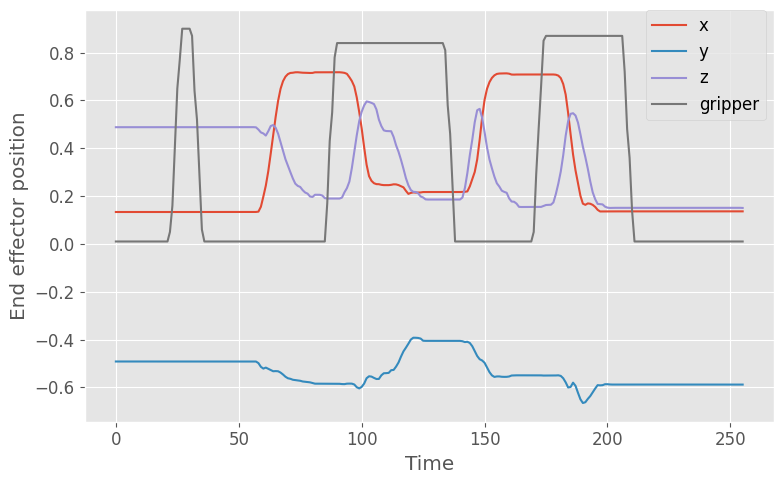

In [32]:
with plt.style.context("ggplot_perso.mplstyle"):
    # with plt.style.context("ggplot"):
    fig, ax = plt.subplots(figsize=(8, 5))
    # cmap = mpl.colormaps.get("tab10").colors
    ax.plot(X_down.index, X_down.x, label="x")  # , color=cmap[0])
    ax.plot(X_down.index, X_down.y, label="y")  # , color=cmap[1])
    ax.plot(X_down.index, X_down.z, label="z")  # , color=cmap[2])
    ax.plot(X_down.index, X_down.gripper, label="gripper")  # , color=cmap[3])
    ax.set_xlabel("Time")
    ax.set_ylabel("End effector position")
    # ax.legend(loc="best")
    ax.legend(bbox_to_anchor=(1.0, 1.02))
    # fig.autofmt_xdate()
    fig.tight_layout()
    plt.show()

In [33]:
minmaxscaler = MinMaxScaler(feature_range=(0, 1))
X_down_scaled = minmaxscaler.fit_transform(X_down)
X_down_scaled

array([[6.65273228e-05, 6.35833273e-01, 7.58165380e-01, ...,
        3.17787547e-09, 1.76097702e-39, 1.04404871e-53],
       [3.63608720e-05, 6.35832226e-01, 7.58209614e-01, ...,
        3.17787547e-09, 1.76097702e-39, 1.04404871e-53],
       [5.96138465e-05, 6.35725193e-01, 7.58246414e-01, ...,
        3.17787547e-09, 1.76097702e-39, 1.04404871e-53],
       ...,
       [4.44448811e-03, 2.82731614e-01, 1.20387506e-03, ...,
        3.17787547e-09, 1.76097702e-39, 1.04404871e-53],
       [4.46953291e-03, 2.82774715e-01, 1.14169091e-03, ...,
        3.17787547e-09, 1.76097702e-39, 1.04404871e-53],
       [4.71642149e-03, 2.82209544e-01, 7.99517778e-05, ...,
        3.17787547e-09, 1.76097702e-39, 1.04404871e-53]], shape=(256, 12))

### Change Point Dectection

In [34]:
# if what_segments == "HigherLevel":
#     # Higher level change points
#     # cpd_segm_penalty = 125
#     cpd_segm_penalty = 9
#     true_chg_pts_iso = [segm["end"] for segm in gt_segm_dict[what_segments].values()]

# cpd_segm_penalty = 2
cpd_segm_penalty = 5
true_chg_pts_iso = []
for idx, skill in enumerate(gt_segm_dict["segments"].values()):
    if isinstance(skill, list):
        for segm in skill:
            if idx == 0:
                true_chg_pts_iso.append(segm["ini"])
            true_chg_pts_iso.append(segm["end"])
    elif isinstance(skill, dict):
        if idx == 0:
            true_chg_pts_iso.append(skill["ini"])
        true_chg_pts_iso.append(skill["end"])

    else:
        raise ValueError("Unexpected value in ground truth JSON file")

true_chg_pts_iso = sorted(list(set(sorted(true_chg_pts_iso))))
true_chg_pts_iso

[1769722509,
 1769722513,
 1769722515,
 1769722520,
 1769722523,
 1769722526,
 1769722528,
 1769722532,
 1769722534]

In [35]:
true_chg_pts = np.empty_like(true_chg_pts_iso) * np.nan
true_chg_pts

array([nan, nan, nan, nan, nan, nan, nan, nan, nan])

In [36]:
for idx in range(len(true_chg_pts)):
    true_chg_pts[idx] = traj[
        traj.timestamp
        >= pd.Timestamp(
            dt.datetime.fromtimestamp(
                true_chg_pts_iso[idx]
            ),  # - dt.timedelta(hours=1),
            tz="EST",
        )
    ].index[0]
# true_chg_pts = [int(item) for item in sorted(list(set(true_chg_pts)))]
true_chg_pts

array([ 4465.,  6463.,  7462.,  9962., 11462., 12961., 13961., 15961.,
       16959.])

In [37]:
true_chg_pts_resampled = [
    round(item * resample_num / X.index.stop) for item in true_chg_pts
]
true_chg_pts_resampled = sorted(list(set(true_chg_pts_resampled)))
true_chg_pts_resampled

[58, 83, 96, 128, 148, 167, 180, 206, 218]

In [38]:
if true_chg_pts_resampled[-1] != resample_num:
    true_chg_pts_resampled.append(resample_num)
true_chg_pts_resampled

[58, 83, 96, 128, 148, 167, 180, 206, 218, 256]

In [39]:
# detection
algo = rpt.Pelt(model="rbf", min_size=2, jump=2).fit(X_down_scaled)
computed_chg_pts = algo.predict(pen=cpd_segm_penalty)
print(computed_chg_pts)

[58, 84, 96, 128, 148, 168, 180, 206, 218, 256]


In [40]:
precision, recall = precision_recall(
    true_chg_pts_resampled, computed_chg_pts, margin=30
)
precision, recall

(0.7777777777777778, 0.7777777777777778)

In [41]:
hausdorff(true_chg_pts_resampled, computed_chg_pts)

np.float64(1.0)

In [42]:
randindex(true_chg_pts_resampled, computed_chg_pts)

0.9979166666666667

In [43]:
def rpt_display(
    signal,
    true_chg_pts,
    computed_chg_pts=None,
    computed_chg_pts_color="red",
    computed_chg_pts_linewidth=4,
    computed_chg_pts_linestyle=(0, (2, 0.5)),
    computed_chg_pts_alpha=0.5,
    ylabels=None,
    **kwargs,
):
    """Display a signal and the change points provided in alternating colors.
    If another set of change point is provided, they are displayed with dashed
    vertical dashed lines. The following matplotlib subplots options is set by
    default, but can be changed when calling `display`):

    - figure size `figsize`, defaults to `(10, 2 * n_features)`.

    Args:
        signal (array): signal array, shape (n_samples,) or (n_samples, n_features).
        true_chg_pts (list): list of change point indexes.
        computed_chg_pts (list, optional): list of change point indexes.
        computed_chg_pts_color (str, optional): color of the lines indicating
            the computed_chg_pts. Defaults to "k".
        computed_chg_pts_linewidth (int, optional): linewidth of the lines
            indicating the computed_chg_pts. Defaults to 3.
        computed_chg_pts_linestyle (str, optional): linestyle of the lines
            indicating the computed_chg_pts. Defaults to "--".
        computed_chg_pts_alpha (float, optional): alpha of the lines indicating
            the computed_chg_pts. Defaults to "1.0".
        **kwargs : all additional keyword arguments are passed to the plt.subplots call.

    Returns:
        tuple: (figure, axarr) with a :class:`matplotlib.figure.Figure` object and an array of Axes objects.
    """
    # COLOR_CYCLE = ["#4286f4", "#f44174"]
    COLOR_CYCLE = mpl.colormaps.get("Pastel2").colors[2:4]

    try:
        import matplotlib.pyplot as plt
    except ImportError:
        raise MatplotlibMissingError(
            "This feature requires the optional dependency matpotlib, you can install it using `pip install matplotlib`."
        )

    if type(signal) != np.ndarray:
        # Try to get array from Pandas dataframe
        signal = signal.values

    if signal.ndim == 1:
        signal = signal.reshape(-1, 1)
    n_samples, n_features = signal.shape

    # let's set a sensible defaut size for the subplots
    matplotlib_options = {
        "figsize": (10, 2 * n_features),  # figure size
    }
    # add/update the options given by the user
    matplotlib_options.update(kwargs)

    # create plots
    fig, axarr = plt.subplots(n_features, sharex=True, **matplotlib_options)

    if n_features == 1:
        axarr = [axarr]

    labels_fontsize = 15
    for idx, (axe, sig) in enumerate(zip(axarr, signal.T)):
        for item in (
            [axe.title, axe.xaxis.label, axe.yaxis.label]
            + axe.get_xticklabels()
            + axe.get_yticklabels()
        ):
            item.set_fontsize(labels_fontsize)
        if TRANSP_BACK_PLOT:
            axe.patch.set_alpha(0)
        axe.tick_params(color="gray")
        axe.spines[["right", "top"]].set_visible(False)
        for spine in axe.spines.values():
            spine.set_edgecolor("gray")
            spine.set_linewidth(1.5)

        color_cycle = cycle(COLOR_CYCLE)
        # plot s
        axe.plot(
            range(n_samples),
            sig,
            color="k",
            lw=computed_chg_pts_linewidth,
            alpha=computed_chg_pts_alpha,
        )
        axe.set_ylabel(ylabels[idx])

        # color each (true) regime
        bkps = [0] + sorted(true_chg_pts)
        # alpha = 0.2  # transparency of the colored background

        for (start, end), col in zip(rpt.utils.pairwise(bkps), color_cycle):
            axe.axvspan(
                max(0, start - 0.5),
                end - 0.5,
                facecolor=col,
                alpha=computed_chg_pts_alpha,
            )
        # vertical lines to mark the computed_chg_pts
        if computed_chg_pts is not None:
            for bkp in computed_chg_pts:
                if bkp != 0 and bkp < n_samples:
                    axe.axvline(
                        x=bkp - 0.5,
                        color=computed_chg_pts_color,
                        linewidth=computed_chg_pts_linewidth,
                        linestyle=computed_chg_pts_linestyle,
                        alpha=computed_chg_pts_alpha,
                        zorder=2.5,
                    )

    axe.set_xlabel("Time steps")
    if TRANSP_BACK_PLOT:
        fig.patch.set_alpha(0)
        # fig.patch.set_facecolor("white")
    fig.tight_layout()

    return fig, axarr

In [44]:
# # display
# with plt.style.context("ggplot_perso.mplstyle"):
#     # rpt.display(minmaxscaler.inverse_transform(X_down_scaled), bkps, result)
#     rpt.display(
#         signal=X_down_scaled,
#         true_chg_pts=true_chg_pts_resampled,
#         computed_chg_pts=computed_chg_pts,
#         figsize=(11, 8),
#     )
#     plt.show()

In [45]:
ylabels = []
count = 1
for label in list(X.columns):
    if "obj" in label:
        label = f"activ {count}"
        count += 1
    ylabels.append(label)
ylabels

['x',
 'y',
 'z',
 'gripper',
 'activ 1',
 'activ 2',
 'activ 3',
 'activ 4',
 'activ 5',
 'activ 6',
 'activ 7',
 'activ 8']

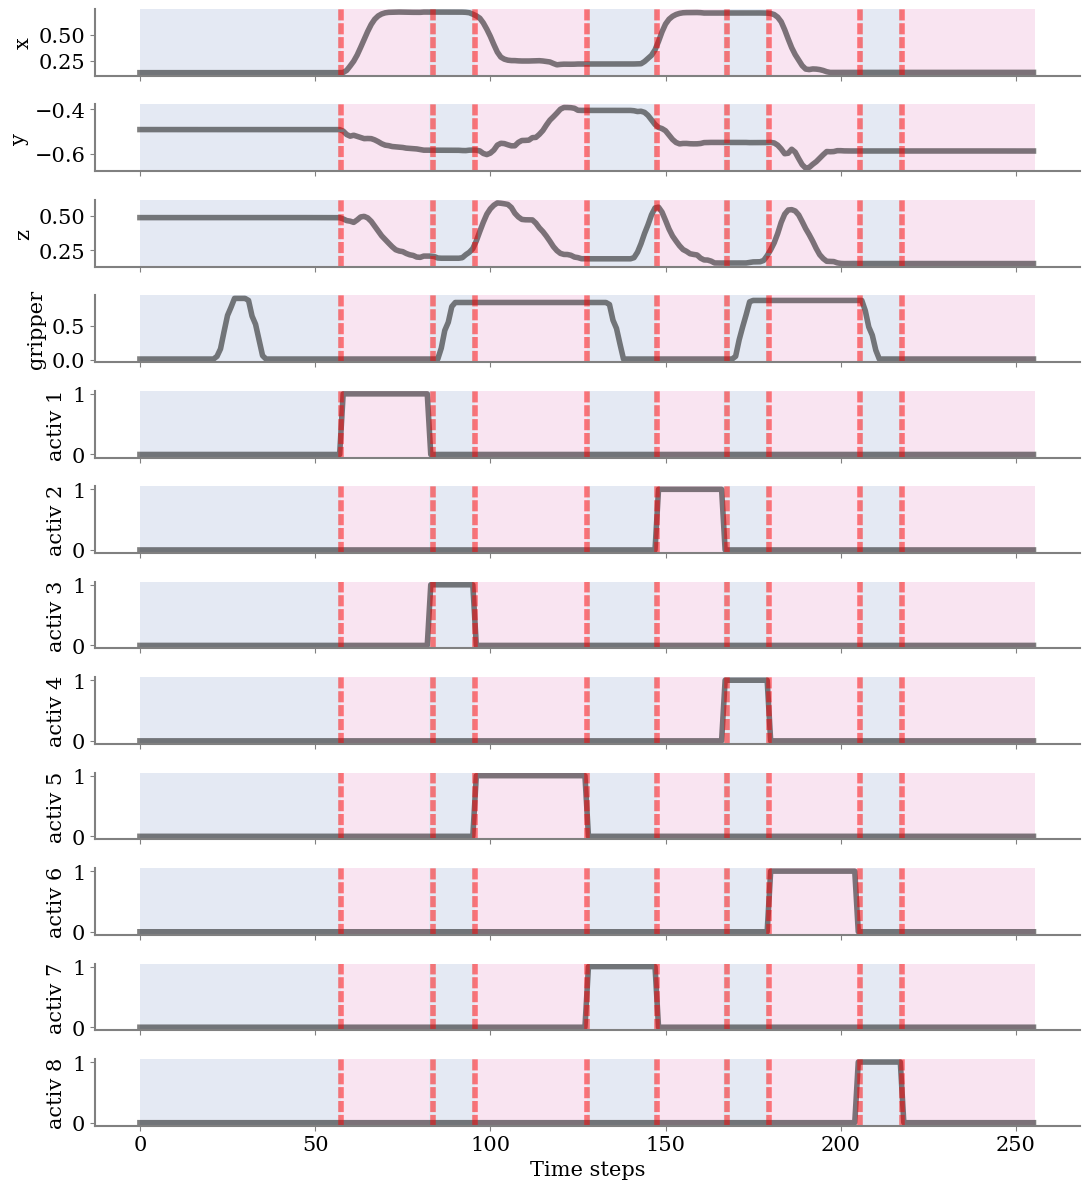

In [46]:
rpt_display(
    signal=X_down,
    computed_chg_pts=computed_chg_pts,
    true_chg_pts=true_chg_pts_resampled,
    ylabels=ylabels,
    figsize=(11, X_down.shape[1]),
)
plt.show()

In [47]:
# ### To be removed
# computed_chg_pts = true_chg_pts_resampled
# ### To be removed

assert len(computed_chg_pts) == len(true_chg_pts_resampled), (
    "CPD method didn't find the right number of segments"
    f"\nTrue changepoint number: {len(true_chg_pts_resampled)}"
    f"\nComputed changepoint number: {len(computed_chg_pts)}"
)

In [48]:
# chg_pts_all = np.concat([[0], computed_chg_pts])
chg_pts_all = computed_chg_pts[:-1]
chg_pts_all

[58, 84, 96, 128, 148, 168, 180, 206, 218]

## Build skills library

In [49]:
colsids2keep = {}
# cols2filter = ["obj_"]
# cols2filter = ["obj_", "accel", "jerk", "curvature", "torsion", "vel"]
# cols2filter = ["obj_", "accel", "jerk", "curvature", "torsion"]
cols2filter = [
    "obj_",
    "accel",
    "jerk",
    "curvature",
    "torsion",
    "_vel",
    "2",
    "xy",
    "xz",
    "yz",
]
# cols2filter = ["accel", "jerk", "curvature", "torsion", "_vel", "2", "xy", "xz", "yz"]
for col_i, col_name in enumerate(X.columns):
    found = None
    for filter_curr in cols2filter:
        if filter_curr in col_name:
            found = True
            break
    if not found:
        colsids2keep[col_i] = col_name
pprint(colsids2keep)
colsids2keep = list(colsids2keep.keys())

{0: 'x', 1: 'y', 2: 'z', 3: 'gripper'}


In [50]:
### Resample segments to the same length
chg_pts_conv_ori = np.array(
    [int(round(item * len(traj) / resample_num)) for item in chg_pts_all]
)
chg_pts_conv_ori

array([ 4502,  6520,  7451,  9935, 11487, 13040, 13971, 15989, 16921])

In [51]:
# similarity_threshold = 0.8
similarity_threshold = 0.5
similarity_threshold = 0.47
# similarity_threshold = 4

In [52]:
# demos = []
# for seg_i, seg_v in enumerate(chg_pts_all[:-1]):
#     # ts_segm = np.arange(start=0, stop=chg_pts_all[seg_i + 1] - chg_pts_all[seg_i])
#     pos_segm = X_down_scaled[chg_pts_all[seg_i] : chg_pts_all[seg_i + 1], 0:4]
#     # demos.append(np.concat((ts_segm[:, np.newaxis], pos_segm), axis=1))
#     print(pos_segm.shape)
#     demos.append(pos_segm)

In [53]:
def resample_array(array, nb_points=256, smoothing_factor=1e-3):
    ori_index = np.arange(array.shape[0])
    new_index = np.linspace(start=0, stop=array.shape[0], num=nb_points)
    arr_resampled = np.ones((nb_points, array.shape[1])) * np.nan
    for colidx, _ in enumerate(range(array.shape[1])):
        arr_resampled[:, colidx] = make_splrep(
            ori_index, array[:, colidx], s=smoothing_factor
        )(new_index)
    return arr_resampled

In [54]:
# def resample_array(traj, n=200):
#     """Resample & smooth a trajectory.
#     Use a univariate spline for each dimension"""
#     n_pts, n_dims = np.shape(traj)
#     # new_traj = np.zeros((n, n_dims+1))
#     new_traj = np.zeros((n, n_dims))
#     t = np.linspace(0, 1, n_pts)
#     tt = np.linspace(0, 1, n)
#     # new_traj[:, 0] = tt
#     for i in range(n_dims):
#         sp = UnivariateSpline(t, traj[:, i].flatten(), s=1e-3)
#         # sp.set_smoothing_factor(1e-3)
#         smooth_resampled = sp(tt)
#         # new_traj[:, i+1] = smooth_resampled
#         new_traj[:, i] = smooth_resampled
#     return new_traj

In [100]:
# smoothing_factor = 1e-6
smoothing_factor = 0

In [101]:
demos = []
for seg_i, seg_v in enumerate(chg_pts_conv_ori[:-1]):
    pos_segm = X.iloc[
        chg_pts_conv_ori[seg_i] : chg_pts_conv_ori[seg_i + 1], colsids2keep  # 0:4
    ].to_numpy()
    pos_segm_resampled = resample_array(
        array=pos_segm, nb_points=resample_num, smoothing_factor=smoothing_factor
    )
    # pos_segm_resampled = resample_array(traj=pos_segm, n=resample_num)
    print(
        f"Original shape: {pos_segm.shape} - resampled shape: {pos_segm_resampled.shape}"
    )
    demos.append(pos_segm_resampled)

Original shape: (2018, 4) - resampled shape: (256, 4)
Original shape: (931, 4) - resampled shape: (256, 4)
Original shape: (2484, 4) - resampled shape: (256, 4)
Original shape: (1552, 4) - resampled shape: (256, 4)
Original shape: (1553, 4) - resampled shape: (256, 4)
Original shape: (931, 4) - resampled shape: (256, 4)
Original shape: (2018, 4) - resampled shape: (256, 4)
Original shape: (932, 4) - resampled shape: (256, 4)


In [102]:
test_metric = distancia.Frechet().calculate
# test_metric = PCA_metric
# test_metric = SimilarityTs_metric

In [103]:
# standardize_data = False
standardize_data = True

In [104]:
weights = np.ones_like(colsids2keep)
weights[3] = 2
weights

array([1, 1, 1, 2])

Class not matched, new class: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.518
Class not matched, new class: 'Skill_1'
Class: 'Skill_0' - Similarity: 0.537
Class: 'Skill_1' - Similarity: 0.564
Class not matched, new class: 'Skill_2'
Class: 'Skill_0' - Similarity: 0.500
Class: 'Skill_1' - Similarity: 0.485
Class: 'Skill_2' - Similarity: 0.552
Class not matched, new class: 'Skill_3'
Class: 'Skill_0' - Similarity: 0.348
Class: 'Skill_1' - Similarity: 0.528
Class: 'Skill_2' - Similarity: 0.447
Class: 'Skill_3' - Similarity: 0.544
Class matched: 'Skill_0'
Class: 'Skill_0' - Similarity: 0.489
Class: 'Skill_1' - Similarity: 0.441
Class: 'Skill_2' - Similarity: 0.541
Class: 'Skill_3' - Similarity: 0.511
Class matched: 'Skill_1'
Class: 'Skill_0' - Similarity: 0.433
Class: 'Skill_1' - Similarity: 0.514
Class: 'Skill_2' - Similarity: 0.320
Class: 'Skill_3' - Similarity: 0.534
Class matched: 'Skill_2'
Class: 'Skill_0' - Similarity: 0.496
Class: 'Skill_1' - Similarity: 0.498
Class: 'Skill_2' - Simila

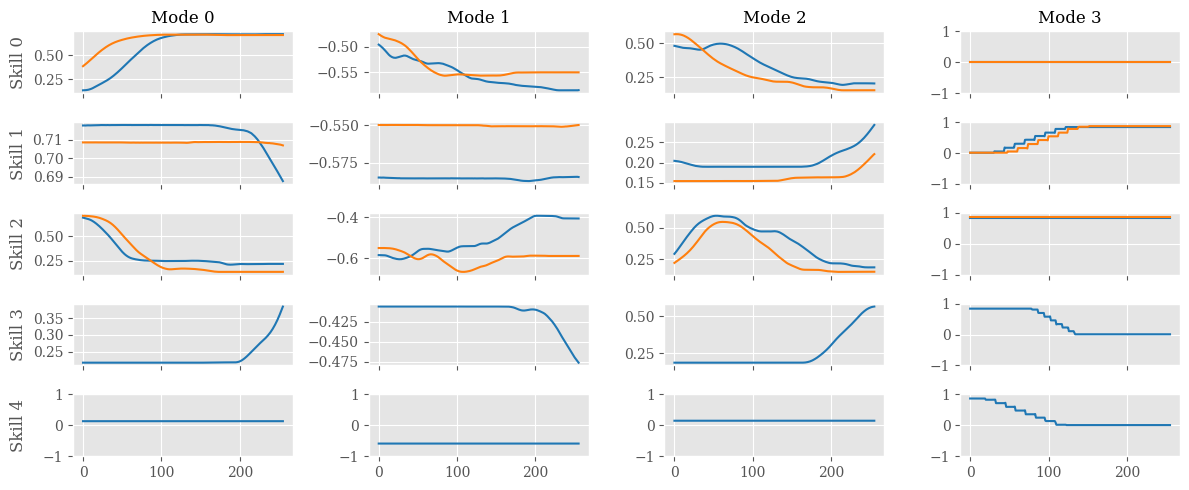

In [107]:
lib_path = Path("lib.h5")
if lib_path.exists():
    lib_path.unlink()
skills_lib = MP_Library(metric=COS_metric, threshold=similarity_threshold, debug=True)
# skills_lib = MP_Library(metric=SSE_metric, threshold=similarity_threshold, debug=True)
# skills_lib = MP_Library(metric=test_metric, threshold=similarity_threshold, debug=True)
# skills_lib = MP_Library(metric=Pearson_metric, threshold=similarity_threshold, debug=True)
for demo_i in demos:
    skills_lib.add_primitive(demo_i, standardize=standardize_data, weights=weights)
skills_lib.display()
skills_lib.plot_separate()
skills_lib.save_h5(lib_path)

In [61]:
# pprint(skills_lib.library)

## LfD learning & stitching

In [62]:
execution_time = 1.0

In [63]:
idx = 0
ts_segm = np.arange(chg_pts_all[idx], chg_pts_all[idx + 1])
ts_segm

array([58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74,
       75, 76, 77, 78, 79, 80, 81, 82, 83])

In [64]:
pos_segm = X_down_scaled[chg_pts_all[idx] : chg_pts_all[idx + 1], colsids2keep]
pos_segm.shape

(26, 4)

In [65]:
n_dims = pos_segm.shape[1]

In [66]:
n_nodes = 35
stretch = 0.005
bend = 0.005
weighting = "uniform"
downsampling = "distance"

In [67]:
lfd_out_txt = list(Path(".").glob("LfD_segm_*.txt"))
lfd_out_txt

[PosixPath('LfD_segm_0.txt'),
 PosixPath('LfD_segm_1.txt'),
 PosixPath('LfD_segm_2.txt'),
 PosixPath('LfD_segm_3.txt'),
 PosixPath('LfD_segm_4.txt'),
 PosixPath('LfD_segm_5.txt'),
 PosixPath('LfD_segm_6.txt'),
 PosixPath('LfD_segm_7.txt')]

In [68]:
if len(list(lfd_out_txt)) > 0:
    for item in list(lfd_out_txt):
        print(item)
        item.unlink()

LfD_segm_0.txt
LfD_segm_1.txt
LfD_segm_2.txt
LfD_segm_3.txt
LfD_segm_4.txt
LfD_segm_5.txt
LfD_segm_6.txt
LfD_segm_7.txt


Constraints:
[[58.     0.135 -0.499  0.478  0.01 ]
 [84.     0.718 -0.585  0.202  0.01 ]]
Start of learned trajectory: [58.016  0.135 -0.499  0.478  0.01 ]
End of learned trajectory: [83.993  0.718 -0.585  0.202  0.01 ]
Constraints:
[[84.     0.718 -0.585  0.202  0.01 ]
 [96.     0.681 -0.585  0.317  0.84 ]]
Start of learned trajectory: [84.018  0.718 -0.585  0.202  0.011]
End of learned trajectory: [95.993  0.682 -0.585  0.316  0.84 ]
Constraints:
[[ 96.      0.681  -0.585   0.317   0.84 ]
 [128.      0.217  -0.406   0.185   0.84 ]]
Start of learned trajectory: [96.011  0.681 -0.585  0.317  0.84 ]
End of learned trajectory: [127.989   0.217  -0.406   0.186   0.84 ]
Constraints:
[[128.      0.217  -0.406   0.185   0.84 ]
 [148.      0.435  -0.482   0.565   0.01 ]]
Start of learned trajectory: [128.017   0.217  -0.406   0.185   0.84 ]
End of learned trajectory: [147.993   0.434  -0.482   0.564   0.01 ]
Constraints:
[[148.      0.435  -0.482   0.565   0.01 ]
 [168.      0.709  -0.55    0

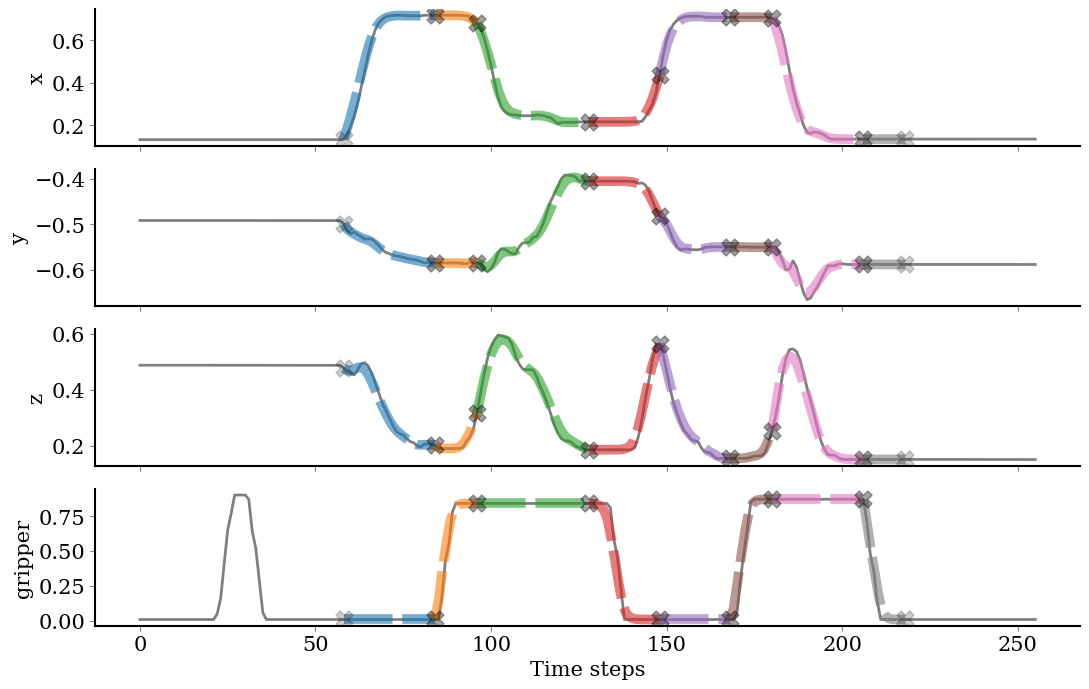

In [69]:
n_nodes_tmp = n_nodes
# with plt.style.context("ggplot_perso.mplstyle"):
fig, axes = plt.subplots(nrows=pos_segm.shape[1], ncols=1, sharex=True, figsize=(11, 7))
cmap = mpl.colormaps.get("Set3").colors
# plt_labels = traj.columns[colsids2keep]
plt_labels = [df_labels[item] for item in colsids2keep]
labels_fontsize = 15
ts = np.arange(stop=X_down_scaled.shape[0])
for axi, axv in enumerate(axes):
    for item in (
        [axv.title, axv.xaxis.label, axv.yaxis.label]
        + axv.get_xticklabels()
        + axv.get_yticklabels()
    ):
        item.set_fontsize(labels_fontsize)
    # axv.plot(X_down_scaled[:, axi], color="k", label="Data", alpha=0.5, lw=2)
    axv.plot(X_down.to_numpy()[:, axi], color="k", label="Data", alpha=0.5, lw=2)
    axv.set_ylabel(plt_labels[axi])
    if TRANSP_BACK_PLOT:
        axv.patch.set_alpha(0)
    axv.tick_params(color="gray")
    axv.spines[["right", "top"]].set_visible(False)
    for spine in axv.spines.values():
        # spine.set_edgecolor("gray")
        spine.set_linewidth(1.5)

# chg_pts_all[-1] = chg_pts_all[-1] - 1
for seg_i, seg_v in enumerate(chg_pts_all[:-1]):
    ## Number of ElMaps nodes can't be greater than the number of data points
    n_nodes = n_nodes_tmp
    num_pts_cur = abs(chg_pts_all[seg_i + 1] - chg_pts_all[seg_i])
    if num_pts_cur < n_nodes:
        n_nodes = num_pts_cur

    ts_segm_ref = np.linspace(
        start=chg_pts_all[seg_i], stop=chg_pts_all[seg_i + 1], num=n_nodes
    )
    # pos_segm = X_down_scaled[chg_pts_all[seg_i] : chg_pts_all[seg_i + 1], colsids2keep]
    pos_segm = X_down.to_numpy()[
        chg_pts_all[seg_i] : chg_pts_all[seg_i + 1], colsids2keep
    ]
    # ts_elmap = np.arange(pos_segm.shape[0])[:, np.newaxis]
    ts_elmap = np.linspace(
        start=chg_pts_all[seg_i], stop=chg_pts_all[seg_i + 1], num=pos_segm.shape[0]
    )[:, np.newaxis]
    traj_to_learn = np.concat((ts_elmap, pos_segm), axis=1)

    elmap = ElmapEM(
        [traj_to_learn],
        n=n_nodes,
        weighting=weighting,
        downsampling=downsampling,
        stretch=stretch,
        bend=bend,
    )
    # constraints = X_down_scaled[[chg_pts_all[seg_i], chg_pts_all[seg_i + 1]], colsids2keep]
    constraints = np.hstack(
        (
            np.array([ts_elmap[0], ts_elmap[-1]]),
            # X_down_scaled[[chg_pts_all[seg_i], chg_pts_all[seg_i + 1]], 0:3],
            # X_down_scaled[:, colsids2keep][
            #     [chg_pts_all[seg_i], chg_pts_all[seg_i + 1]], :
            # ],
            X_down.to_numpy()[:, colsids2keep][
                [chg_pts_all[seg_i], chg_pts_all[seg_i + 1]], :
            ],
        )
    )

    # # To be removed
    # if seg_i == 6:
    #     constraints[-1, 2] += 0.09
    # if seg_i == 7:
    #     constraints[0, 2] += 0.09

    with np.printoptions(precision=3, suppress=True):
        print(f"Constraints:\n{constraints}")
    new_traj = elmap.optimize_map(
        consts=constraints,
        inds=[0, n_nodes - 1],
    )
    new_traj_end = new_traj[:, 1:]
    with np.printoptions(precision=3, suppress=True):
        print(f"Start of learned trajectory: {new_traj[0]}")
        print(f"End of learned trajectory: {new_traj[-1]}")
    # new_traj_unscaled = minmaxscaler.inverse_transform(
    #     np.hstack((new_traj_end, np.zeros((new_traj_end.shape[0], nsegments))))
    # )[:, colsids2keep]
    np.savetxt(
        f"LfD_segm_{seg_i}.txt",
        # new_traj_unscaled,
        new_traj_end,
        delimiter=",",
        header=", ".join(list(plt_labels))
        + f"\n{[int(item) for item in true_chg_pts]}",
    )

    for axi, axv in enumerate(axes):
        axv.plot(
            ts_segm_ref,
            new_traj_end[:, axi],
            linestyle=(0, (5, 1)),
            # color=cmap[seg_i],
            label=f"LfD {seg_i}",
            lw=7,
            alpha=0.6,
        )
        axv.scatter(
            ts_segm_ref[0],
            constraints[0, axi + 1],
            marker="X",
            color="k",
            alpha=0.2,
            zorder=2.5,
            s=150,
        )
        axv.scatter(
            ts_segm_ref[-1],
            constraints[-1, axi + 1],
            marker="X",
            color="k",
            alpha=0.2,
            zorder=2.5,
            s=150,
        )

axes[-1].set_xlabel("Time steps")
# axes[-1].legend(bbox_to_anchor=(1, -0.5), ncol=6, fontsize=labels_fontsize)
if TRANSP_BACK_PLOT:
    fig.patch.set_alpha(0)
    # fig.patch.set_facecolor("white")
fig.tight_layout()

plt.show()